<a href="https://colab.research.google.com/github/Delna-Thomas/Internship-2026/blob/main/VGG16_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Import required libraries***

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications  import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical


***Load and sample fashion_MNIST dataset***

In [2]:
(x_train, y_train),(x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train,y_train=x_train[:100],y_train[:100]
x_test,y_test=x_test[:100],y_test[:100]

***Resize images to 224 * 224***

In [4]:
x_train=tf.image.resize(x_train,(224,224))
x_test=tf.image.resize(x_test,(224,224))

***Normalization***

In [5]:
x_train=x_train/255.0
x_test=x_test/255.0

***One hot encoding***

In [13]:
(_,y_train_full),(_,y_test_full)=tf.keras.datasets.fashion_mnist.load_data()
y_train=y_train_full[:100]
y_test=y_test_full[:100]
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)

***Load Pretrained VGG16 without top layers***

In [7]:
base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


***Freeze Basemodel layers(Feature extraction)***

In [8]:
for layer in base_model.layers:
  layer.trainable=False

***Add custom top layers***

In [9]:
x=base_model.output
x=Flatten()(x)
x=Dense(256,activation="relu")(x)
x=Dropout(0.5)(x)
predictions=Dense(10,activation="softmax")(x)

***Create the final model***

In [10]:
model=Model(inputs=base_model.input,outputs=predictions)

***Compile the model(Feature extraction Phase)***

In [11]:
model.compile(optimizer=Adam(learning_rate=1e-4),loss='categorical_crossentropy',metrics=['accuracy'])

***Train the model(Only top layers)***

In [15]:
(raw_x_train,raw_y_train),(_,_)=tf.keras.datasets.fashion_mnist.load_data()
x_train_processed=raw_x_train[:100]
y_train_processed=raw_y_train[:100]
x_train_processed=tf.cast(x_train_processed,tf.float32)/255.0
x_train_processed=tf.expand_dims(x_train_processed,axis=-1)
x_train_processed=tf.image.resize(x_train_processed,(224,224))
x_train_processed=tf.image.grayscale_to_rgb(x_train_processed)
y_train_processed=to_categorical(y_train_processed)
y_train_processed=tf.cast(y_train_processed,tf.float32)
print("Shape of x_train_processed before model.fit:{x_train_processed.shape}")
print("Shape of y_train_processed before model.fit:{y_train_processed.shape}")
history=model.fit(x_train_processed.numpy(),y_train_processed.numpy(),epochs=5,batch_size=32,validation_split=0.2)

Shape of x_train_processed before model.fit:{x_train_processed.shape}
Shape of y_train_processed before model.fit:{y_train_processed.shape}
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 67s 24s/step - accuracy: 0.4750 - loss: 1.4768 - val_accuracy: 0.8000 - val_loss: 1.1586
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 20s/step - accuracy: 0.5625 - loss: 1.2806 - val_accuracy: 0.7000 - val_loss: 1.1040
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 24s/step - accuracy: 0.7000 - loss: 1.0223 - val_accuracy: 0.6000 - val_loss: 1.1055
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 24s/step - accuracy: 0.6875 - loss: 0.9217 - val_accuracy: 0.6000 - val_loss: 1.0528
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 73s 20s/step - accuracy: 0.8000 - loss: 0.7874 - val_accuracy: 0.7000 - val_loss: 0.9458


***Fine-tune some convolutional Leyars***

In [17]:
for layer in base_model.layers[-4:]:
  layer.trainable=True

***compile again(after unfreezing)***

In [ ]:

model.compile(optimizer=Adam(learning_rate=1e-5),loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
(raw_x_train,raw_y_train),(_,_)=tf.keras.datasets.fashion_mnist.load_data()
x_train_fine=raw_x_train[:100]
y_train_fine=raw_y_train[:100]
x_train_fine=tf.cast(x_train_fine,tf.float32)/255.0
x_train_fine=tf.expand_dims(x_train_fine,axis=-1)
x_train_fine=tf.image.resize(x_train_fine,(224,224))
x_train_fine=tf.image.grayscale_to_rgb(x_train_fine)
y_train_fine=to_categorical(y_train_fine)
y_train_fine=tf.cast(y_train_fine,tf.float32)
print("Shape of x_train_fine before model.fit:{x_train_fine.shape}")
print("Shape of y_train_fine before model.fit:{y_train_fine.shape}")
history_fine=model.fit(x_train_fine.numpy(),y_train_fine.numpy(),epochs=5,batch_size=32,validation_split=0.2)

Shape of x_train_fine before model.fit:{x_train_fine.shape}
Shape of y_train_fine before model.fit:{y_train_fine.shape}
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 90s 32s/step - accuracy: 0.8125 - loss: 0.6723 - val_accuracy: 0.7000 - val_loss: 0.8539
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 131s 27s/step - accuracy: 0.8375 - loss: 0.5925 - val_accuracy: 0.6500 - val_loss: 0.8048
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 33s/step - accuracy: 0.9125 - loss: 0.5187 - val_accuracy: 0.6500 - val_loss: 0.8248
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 134s 29s/step - accuracy: 0.8250 - loss: 0.5074 - val_accuracy: 0.7500 - val_loss: 0.7752
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 20s/step - accuracy: 0.8375 - loss: 0.4785 - val_accuracy: 0.7500 - val_loss: 0.7262


**Evaluate on test sett**

In [20]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
(raw_x_test,raw_y_test),(_,_)=tf.keras.datasets.fashion_mnist.load_data()
x_test_processed=raw_x_test[:100]
y_test_processed=raw_y_test[:100]
x_test_processed=tf.cast(x_test_processed,tf.float32)/255.0
x_test_processed=tf.expand_dims(x_test_processed,axis=-1)
x_test_processed=tf.image.resize(x_test_processed,(224,224))
x_test_processed=tf.image.grayscale_to_rgb(x_test_processed)
y_test_processed=to_categorical(y_test_processed)
y_test_processed=tf.cast(y_test_processed,tf.float32)
print("Shape of x_test_processed before model.evaluate:{x_test_processed.shape}")
print("Shape of y_test_processed before model.evaluate:{y_test_processed.shape}")
test_loss,test_acc=model.evaluate(x_test_processed.numpy(),y_test_processed.numpy())
print("Test accuracy:",test_acc)
print("Test loss:",test_loss)


Shape of x_test_processed before model.evaluate:{x_test_processed.shape}
Shape of y_test_processed before model.evaluate:{y_test_processed.shape}
4/4 ━━━━━━━━━━━━━━━━━━━━ 73s 14s/step - accuracy: 0.9400 - loss: 0.3734
Test accuracy: 0.9399999976158142
Test loss: 0.37343934178352356


***Plot accuracy graph***

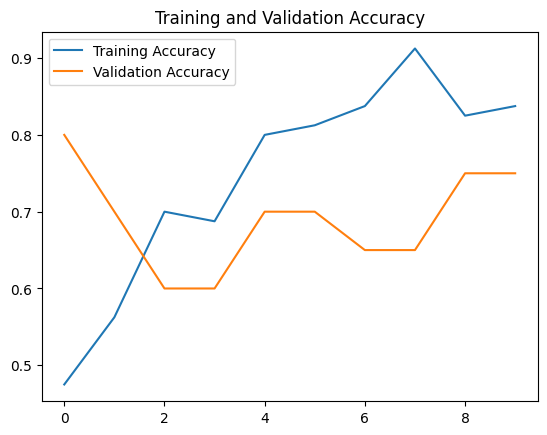

In [21]:
plt.plot(history.history['accuracy']+history_fine.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy']+history_fine.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()